In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/online_retail_preprocessed.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset Shape:", df.shape)

Dataset Shape: (1003758, 14)


In [2]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_df = df[df["Customer ID"] != "Unknown"].copy()

rfm = customer_df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print("RFM Shape:", rfm.shape)
rfm.head()

RFM Shape: (5853, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,1658.40
12349.0,19,3,3678.69
12350.0,310,1,294.40


In [3]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("RFM data scaled successfully.")
print("Shape:", rfm_scaled.shape)

RFM data scaled successfully.
Shape: (5853, 3)


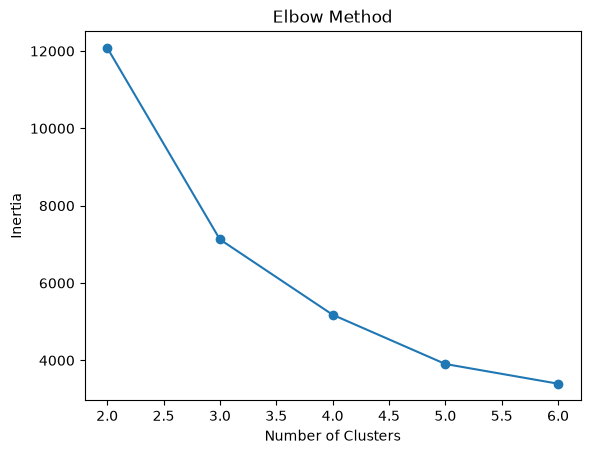

In [4]:
inertia = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(range(2, 7), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Clustering completed.")

Clustering completed.


In [6]:
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,67.11,7.22,2878.34
1,3.50,202.75,422987.81
2,461.68,2.22,723.88
3,24.26,99.24,76993.61


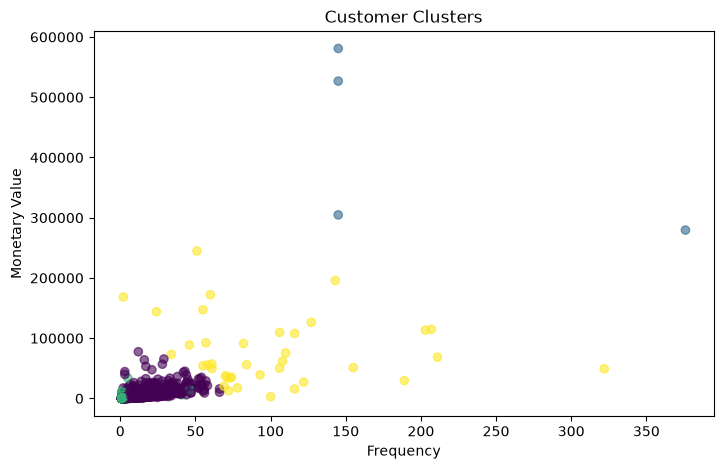

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Clusters")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.show()

In [8]:
cluster_size = rfm["Cluster"].value_counts().sort_index()
cluster_size

Cluster
0    3833
1       4
2    1978
3      38
Name: count, dtype: int64